# Étape 7 — Analyse du data drift

Objectif : définir des indicateurs concrets pour détecter un changement dans la distribution des données de production par rapport aux données d'entraînement, et proposer une stratégie d'alerte / réentraînement.

On réutilise le split chronologique de `ExamenML.ipynb` : la période d'entraînement (jusqu'à 2024-05) sert de **référence**, la période de test (2024-06 à 2025-06) simule des **données récentes** — exactement le type de comparaison qu'on ferait en production entre les données d'entraînement et un nouveau batch mensuel.

Trois niveaux de dérive à surveiller :
1. **Data drift** (covariate shift) : distribution des features d'entrée.
2. **Prediction drift** : distribution des scores prédits par le modèle — utilisable **en temps réel**, car contrairement aux vraies étiquettes (`conflict_escalation_6m`), disponibles avec 6 mois de retard, les prédictions sont immédiates.
3. **Concept/target drift** : quand les vraies étiquettes arrivent enfin, comparer la performance réelle du modèle à celle mesurée à l'entraînement.


In [1]:
import joblib
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.max_columns", 50)

# Reprend exactement le nettoyage / feature engineering de l'Étape 2 (ExamenML.ipynb)
df = pd.read_csv("geopolitical_conflict_risk_dataset.csv")
df = df.drop(columns=["election_cycle", "instability_score", "political_stability_index"])

df["month_date"] = pd.to_datetime(df["month"], format="%Y-%m")
df["month_sin"] = np.sin(2 * np.pi * df["month_date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month_date"].dt.month / 12)
df["no_prior_conflict_on_record"] = (df["last_conflict_year"] == 0).astype(int)
years_since = df["month_date"].dt.year - df["last_conflict_year"]
df["years_since_last_conflict"] = years_since.where(df["last_conflict_year"] != 0)
df["protest_acceleration"] = df["protest_events_last_3m"] - df["rolling_protest_avg_6m"]
df["economic_pressure_index"] = df["inflation_rate"] + df["unemployment_rate"] + df["food_price_index"] / 10
df = df.drop(columns=["month", "last_conflict_year"])

cutoff_date = df.sort_values("month_date")["month_date"].quantile(0.8, interpolation="nearest")
reference = df[df["month_date"] <= cutoff_date].drop(columns="month_date")
current = df[df["month_date"] > cutoff_date].drop(columns="month_date")

model = joblib.load("model.joblib")
numeric_features = reference.select_dtypes("number").columns.drop("conflict_escalation_6m").tolist()
categorical_features = ["country", "region", "regime_type"]

print(f"Référence (entraînement) : {reference.shape}, récent (test) : {current.shape}")


Référence (entraînement) : (1060, 27), récent (test) : (260, 27)


## 1. Data drift — features numériques

Deux indicateurs complémentaires, calculés **par feature** :
- **PSI (Population Stability Index)** : mesure standard en risque/scoring bancaire. Seuils usuels : `< 0.1` pas de dérive, `0.1–0.2` dérive modérée à surveiller, `> 0.2` dérive significative.
- **Test de Kolmogorov-Smirnov** : teste si les deux échantillons proviennent de la même distribution (p-value < 0.05 = dérive statistiquement significative).


In [2]:
def population_stability_index(reference_values, current_values, bins=10):
    ref = pd.Series(reference_values).dropna()
    cur = pd.Series(current_values).dropna()

    quantile_edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    quantile_edges[0], quantile_edges[-1] = -np.inf, np.inf
    if len(quantile_edges) < 3:
        return 0.0  # feature quasi constante : pas de dérive mesurable par quantiles

    ref_counts = pd.cut(ref, quantile_edges).value_counts(sort=False) / len(ref)
    cur_counts = pd.cut(cur, quantile_edges).value_counts(sort=False) / len(cur)

    eps = 1e-4  # évite log(0) / division par 0 sur les buckets vides
    ref_pct = ref_counts.clip(lower=eps)
    cur_pct = cur_counts.clip(lower=eps)
    return float(((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)).sum())


drift_rows = []
for col in numeric_features:
    psi = population_stability_index(reference[col], current[col])
    ks_stat, ks_pvalue = stats.ks_2samp(reference[col].dropna(), current[col].dropna())
    drift_rows.append({"feature": col, "psi": psi, "ks_statistic": ks_stat, "ks_pvalue": ks_pvalue})

drift_report = pd.DataFrame(drift_rows).set_index("feature").sort_values("psi", ascending=False)
drift_report["drift_alert"] = (drift_report["psi"] > 0.2) | (drift_report["ks_pvalue"] < 0.05)
drift_report


,psi,ks_statistic,ks_pvalue,drift_alert
feature,,,,
years_since_last_conflict,3.533708,0.412571,9.711789e-26,True
protest_acceleration,0.114185,0.101959,2.402089e-02,True
energy_dependency_pct,0.087839,0.069448,2.528042e-01,False
arms_imports_index,0.077936,0.103628,2.077934e-02,True
month_sin,0.073757,0.087083,7.881940e-02,False
protest_events_last_3m,0.064152,0.058563,4.517309e-01,False
unemployment_rate,0.063757,0.072932,2.051316e-01,False
rolling_protest_avg_6m,0.049077,0.074456,1.865845e-01,False
month_cos,0.047787,0.079826,1.314970e-01,False


**Lecture des résultats** :
- `years_since_last_conflict` affiche un PSI énorme (3.53) — attendu et **non pathologique** : c'est une fonction déterministe du temps calendaire pour un événement passé fixe (elle augmente mécaniquement chaque mois), donc sa distribution "récente" est structurellement décalée par rapport à la référence. Un vrai système de monitoring devrait **exclure ce type de feature temporelle du calcul de drift** (ou suivre sa dérive attendue séparément), sous peine de fausses alertes permanentes.
- `protest_acceleration` et `arms_imports_index` montrent une dérive statistiquement significative mais modérée (PSI ≈ 0.08-0.11, KS p-value < 0.05) — à surveiller, sans déclencher d'alerte à elles seules.
- Toutes les autres features restent stables (PSI < 0.1, p-value > 0.05) : pas de dérive préoccupante sur la période de test.


## 2. Data drift — features catégorielles

Test du **Chi² d'indépendance** sur les tables de contingence (référence vs récent) pour `country`, `region`, `regime_type`.


In [3]:
categorical_drift_rows = []
for col in categorical_features:
    contingency = pd.concat(
        [reference[col].value_counts().rename("reference"), current[col].value_counts().rename("current")],
        axis=1,
    ).fillna(0)
    chi2, chi2_pvalue, _, _ = stats.chi2_contingency(contingency.T)
    categorical_drift_rows.append({"feature": col, "chi2_statistic": chi2, "chi2_pvalue": chi2_pvalue})

categorical_drift_report = pd.DataFrame(categorical_drift_rows).set_index("feature")
categorical_drift_report["drift_alert"] = categorical_drift_report["chi2_pvalue"] < 0.05
categorical_drift_report


,chi2_statistic,chi2_pvalue,drift_alert
feature,,,
country,0.000000,1.000000,False
region,0.000000,1.000000,False
regime_type,2.418209,0.298464,False


## 3. Prediction drift

Contrairement aux vraies étiquettes (`conflict_escalation_6m`), connues seulement 6 mois plus tard, **les probabilités prédites par le modèle sont disponibles immédiatement** pour chaque nouveau batch — c'est l'indicateur le plus utile pour une surveillance en quasi temps réel. On compare la distribution des scores prédits sur la référence vs le batch récent.


PSI des scores prédits       : 0.1893
KS des scores prédits        : stat=0.1032, p-value=0.0216
Taux d'alerte moyen (réf.)   : 39.34%
Taux d'alerte moyen (récent) : 36.15%


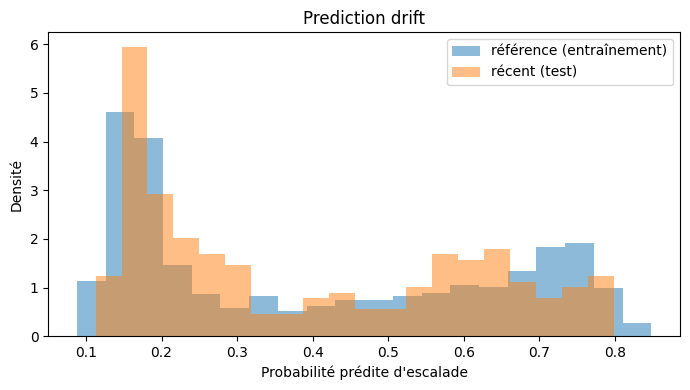

In [4]:
reference_proba = model.predict_proba(reference.drop(columns="conflict_escalation_6m"))[:, 1]
current_proba = model.predict_proba(current.drop(columns="conflict_escalation_6m"))[:, 1]

proba_psi = population_stability_index(reference_proba, current_proba)
proba_ks_stat, proba_ks_pvalue = stats.ks_2samp(reference_proba, current_proba)

print(f"PSI des scores prédits       : {proba_psi:.4f}")
print(f"KS des scores prédits        : stat={proba_ks_stat:.4f}, p-value={proba_ks_pvalue:.4f}")
print(f"Taux d'alerte moyen (réf.)   : {(reference_proba >= 0.5).mean():.2%}")
print(f"Taux d'alerte moyen (récent) : {(current_proba >= 0.5).mean():.2%}")

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(reference_proba, bins=20, alpha=0.5, density=True, label="référence (entraînement)")
plt.hist(current_proba, bins=20, alpha=0.5, density=True, label="récent (test)")
plt.xlabel("Probabilité prédite d'escalade")
plt.ylabel("Densité")
plt.title("Prediction drift")
plt.legend()
plt.tight_layout()
plt.show()


PSI = 0.19 (juste sous le seuil de 0.2) et KS significatif (p = 0.02) : dérive **modérée mais réelle** des scores prédits, avec un taux d'alerte moyen qui baisse de 39 % à 36 %. Cohérent avec le léger data drift déjà repéré sur `protest_acceleration`/`arms_imports_index` : à surveiller de près au prochain batch, sans déclencher de réentraînement immédiat (sous le seuil de 0.2).


## 4. Concept drift — performance réelle une fois les étiquettes disponibles

⚠️ Comparer le score métier **train vs test** ne mesure pas le concept drift : le train est par construction plus favorable au modèle (c'est sur ces données qu'il a été ajusté), donc un écart train/test est surtout un écart de généralisation normal, pas une preuve de dérive. Le bon **baseline de référence** à utiliser en production est le score métier obtenu sur le jeu de test **au moment du déploiement** (celui calculé à l'Étape 4 : 0.582 pour Random Forest) — c'est cette valeur qu'on doit comparer au score recalculé sur un futur batch labellisé, une fois les vraies étiquettes disponibles (avec le décalage de 6 mois inhérent à la cible). Une chute significative sous ce baseline de déploiement indiquerait un concept drift réel.


In [5]:
from sklearn.metrics import confusion_matrix

COST_FP, COST_FN = 1, 5  # doit rester identique à la définition de l'Étape 3 (ExamenML.ipynb)


def business_score(y_true, y_pred, cost_fp=COST_FP, cost_fn=COST_FN):
    y_true = np.asarray(y_true)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    model_cost = cost_fp * fp + cost_fn * fn
    naive_cost = cost_fn * y_true.sum()
    return 1 - model_cost / naive_cost if naive_cost else (1.0 if model_cost == 0 else 0.0)


train_fit_score = business_score(reference["conflict_escalation_6m"], (reference_proba >= 0.5).astype(int))
deployment_baseline_score = business_score(current["conflict_escalation_6m"], (current_proba >= 0.5).astype(int))

print(f"Score métier — train (ajustement, indicatif)     : {train_fit_score:.3f}")
print(f"Score métier — test = baseline de déploiement    : {deployment_baseline_score:.3f}")
print(
    "\nEn production : recalculer ce score sur chaque futur batch labellisé (6 mois de "
    f"décalage) et comparer à {deployment_baseline_score:.3f}, pas au score d'entraînement."
)


Score métier — train (ajustement, indicatif)     : 0.820
Score métier — test = baseline de déploiement    : 0.582

En production : recalculer ce score sur chaque futur batch labellisé (6 mois de décalage) et comparer à 0.582, pas au score d'entraînement.


## 5. Stratégie de surveillance et de réentraînement

**Indicateurs suivis en continu (dashboard mensuel)**
| Indicateur | Fréquence | Seuil d'alerte |
|---|---|---|
| PSI par feature numérique (hors features temporelles déterministes) | à chaque batch mensuel | > 0.2 sur ≥ 1 feature clé (`protest_events_last_3m`, `rolling_protest_avg_6m`, `sanctions_active`) ou > 0.1 sur ≥ 3 features |
| Chi² sur les features catégorielles | mensuel | p-value < 0.05 |
| PSI / KS des scores prédits | à chaque batch (temps réel) | PSI > 0.2 |
| Taux moyen d'alerte du modèle | mensuel | variation > ±10 points vs référence |
| Score métier réel (une fois les étiquettes connues, +6 mois) | trimestriel | chute > 0.10 sous le baseline de déploiement |

**Stratégie d'alerte** : un email/Slack automatique à l'équipe data si un des seuils ci-dessus est dépassé (implémentable simplement en loggant ces métriques dans MLflow à chaque run de scoring, avec une alerte déclenchée par un job planifié qui compare aux valeurs de référence).

**Stratégie de réentraînement** :
- **Réentraînement programmé** : tous les trimestres, avec les données les plus récentes, en gardant le même pipeline (Étapes 2-4) et en comparant le nouveau modèle au modèle en production sur le score métier avant de le promouvoir (approche *champion/challenger*, traçable dans MLflow via le tag `stage=selected_for_deployment`).
- **Réentraînement déclenché** : si le data drift ou le prediction drift dépasse les seuils ci-dessus *avant* l'échéance trimestrielle, ou si le score métier réel chute significativement sous le baseline de déploiement une fois les étiquettes disponibles.
- **Garde-fou** : ne jamais déployer automatiquement un nouveau modèle dont le score métier sur un jeu de validation récent est inférieur à celui du modèle en production — la promotion reste une décision validée (manuellement ou via un seuil strict) avant bascule.

## Synthèse Étape 7

- **Data drift** : globalement stable. Seule exception notable, `years_since_last_conflict`, dont la dérive est structurelle (fonction du temps) et non préoccupante ; `protest_acceleration` et `arms_imports_index` montrent une dérive modérée à surveiller.
- **Prediction drift** : PSI = 0.19, juste sous le seuil d'alerte — dérive réelle mais modérée, cohérente avec les features ci-dessus.
- **Concept drift** : pas mesurable directement ici faute d'un troisième batch réellement futur ; le baseline de déploiement à utiliser pour la suite est le score métier du jeu de test (0.582), pas celui du train.
- En production réelle, ce même notebook tournerait mensuellement sur les nouvelles données pour détecter une dérive plus marquée que celle observée ici (train/test provenant de la même génération de données).
